# Midterm Notebook: Predicting Customer Response to an Outreach Campaign

**Amrit Dhillon**

# 1. Exploratory Data Analysis

**Include a small number of relevant summaries or plots and focus on insights that influenced your modeling.**

In [1]:
#imports for EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
import warnings
warnings.filterwarnings("ignore")

Train shape: (32950, 23)


,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1



accepted_offer counts:
accepted_offer
0    29235
1     3715
Name: count, dtype: int64

accepted_offer rate: 0.1127


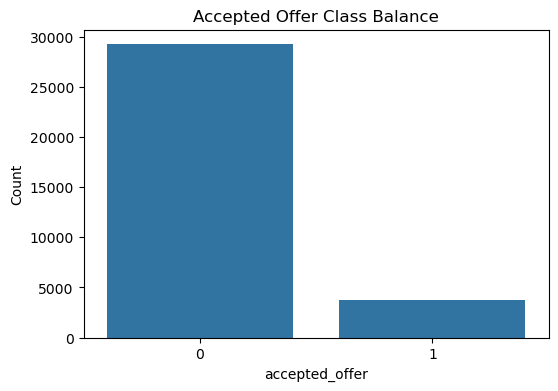

In [2]:
#loading in train data
train = pd.read_csv("/Users/amritdhillon/Desktop/Advanced ML/MidtermCode/midterm_train.csv")
data_dict = pd.read_csv("/Users/amritdhillon/Desktop/Advanced ML/MidtermCode/midterm_data_dictionary.csv")

#see what the data looks like
print("Train shape:", train.shape)
display(train.head(5))

#see distribution and accepted offer rate
target_counts = train["accepted_offer"].value_counts().sort_index()
target_rate = train["accepted_offer"].mean()

print("\naccepted_offer counts:")
print(target_counts)
print(f"\naccepted_offer rate: {target_rate:.4f}")

plt.figure(figsize=(6,4))
sns.countplot(data=train, x="accepted_offer")
plt.title("Accepted Offer Class Balance")
plt.xlabel("accepted_offer")
plt.ylabel("Count")
plt.show()


In [3]:
#count of  "unknown" appearing in categorical columns in descending order
obj_cols = train.select_dtypes(include="object").columns
unknown_counts = pd.Series({c: (train[c] == "unknown").sum() for c in obj_cols}).sort_values(ascending=False)
display(unknown_counts[unknown_counts > 0].to_frame("unknown_count"))

,unknown_count
has_credit_issue,6858
education_background,1406
mortgage_status,786
personal_loan_status,786
occupation_type,262
relationship_status,68


,mean,count
prior_outcome_status,,
success,0.636607,1120
failure,0.142392,3378
nonexistent,0.088605,28452


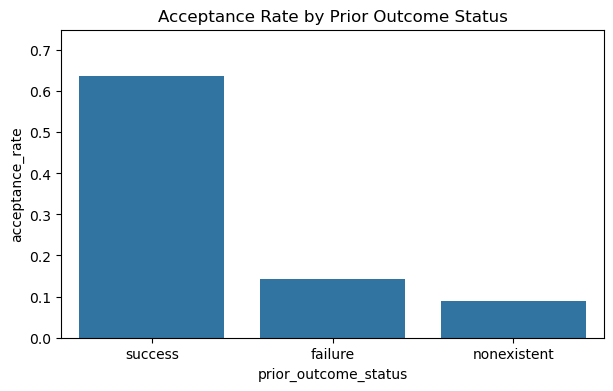

In [4]:
#visual comparing prior outcome status vs acceptance rate
#easily visible that acceptance rate much higher for those previously successful
prior_outcome = (
    train.groupby("prior_outcome_status")["accepted_offer"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
display(prior_outcome)

plt.figure(figsize=(7,4))
sns.barplot(data=prior_outcome.reset_index(), x="prior_outcome_status", y="mean")
plt.title("Acceptance Rate by Prior Outcome Status")
plt.xlabel("prior_outcome_status")
plt.ylabel("acceptance_rate")
plt.ylim(0, 0.75)
plt.show()


,mean,count
last_contact_month,,
mar,0.513761,436
dec,0.475862,145
sep,0.457082,466
oct,0.431818,572
apr,0.209160,2118
aug,0.103922,4946
jun,0.103238,4262
nov,0.101767,3282
jul,0.091590,5743


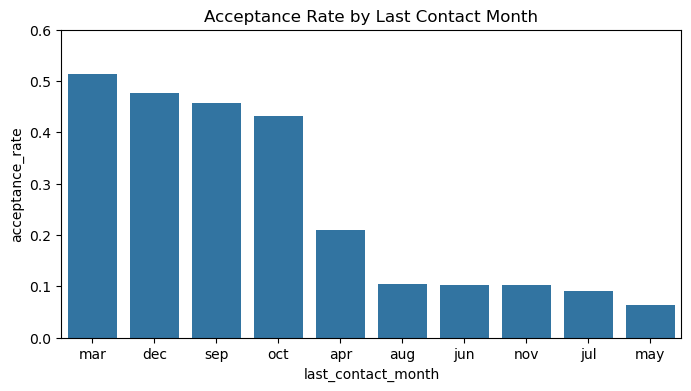

In [5]:
#visual comparing last contact month vs acceptance rate
#evident that several months have much higher acceptance rates
month_perf = (
    train.groupby("last_contact_month")["accepted_offer"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
display(month_perf)

plt.figure(figsize=(8,4))
sns.barplot(data=month_perf.reset_index(), x="last_contact_month", y="mean")
plt.title("Acceptance Rate by Last Contact Month")
plt.xlabel("last_contact_month")
plt.ylabel("acceptance_rate")
plt.ylim(0, 0.6)
plt.show()

In [6]:
#correlations of all numeric features with accepted_target sorted bby magnitude
#top 10 features most strongly related to accepted_offer by magnitude are displayed
num_cols = train.select_dtypes(include=[np.number]).columns
corr_target = train[num_cols].corr(numeric_only=True)["accepted_offer"].drop("accepted_offer").sort_values(key=lambda s: s.abs(), ascending=False)
display(corr_target.head(10).to_frame("corr_with_accepted_offer"))


,corr_with_accepted_offer
contact_time_minutes,0.404403
employment_level_index,-0.355823
days_since_prior_contact,-0.320040
recent_contact_flag,0.319990
reference_interest_rate,-0.308602
economic_activity_change,-0.298351
prior_contact_count,0.229570
is_repeat_customer,0.191969
consumer_price_index,-0.134264
contact_attempt_count,-0.065250


**Summary of Initial EDA Findings**

- The outcome variable accepted_offer is highly imbalanced (~11% accepted vs ~89% not accepted), so model performance metrics beyond accuracy will be important

- Prior outcome status seems to be very predictive as previous success has ~64% acceptance vs less than 15% otherwise

- Certain months (Mar, Dec, Sep, Oct) have much higher acceptance rates than others (ex: May, Jul)

- Several categorical fields contain unknown values, especially has_credit_issue, which may need to be considered for encoding

- From the correlations found the most important numeric drivers are:
    - Positive: contact_time_minutes, recent_contact_flag, prior_contact_count, is_repeat_customer
    - Negative: employment_level_index, days_since_prior_contact, reference_interest_rate, economic_activity_change  

- Based on this it seems like features involving customer engagement like recent_contact_flag and days_since_prior_contact are most predictive

# 2. Data Preparation

**Show the preprocessing steps used for modeling.**

In [7]:
#imports for data preparation
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [8]:
#loading in test data now too
test = pd.read_csv("/Users/amritdhillon/Desktop/Advanced ML/MidtermCode/midterm_test.csv")

#separate id columns to keep for final predictions later, going to be removing for modeling
train_ids = train["id"].copy()
test_ids = test["id"].copy()

#target and feature split
y = train["accepted_offer"].astype(int)
X = train.drop(columns=["accepted_offer", "id"]).copy()
X_test = test.drop(columns=["id"]).copy()

#check to make sure counts look good after dropping
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (32950, 21)
y shape: (32950,)
X_test shape: (8238, 21)


In [9]:
#separating numeric and categorical columns for preprocessing, displaying the categorical feature count
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric feature count:", len(numeric_features))
print("Categorical feature count:", len(categorical_features))
display(pd.Series(categorical_features, name="categorical_features"))


Numeric feature count: 12
Categorical feature count: 9


0         occupation_type
1     relationship_status
2    education_background
3        has_credit_issue
4         mortgage_status
5    personal_loan_status
6      last_contact_month
7             day_of_week
8    prior_outcome_status
Name: categorical_features, dtype: object

In [10]:
#preprocessing pipeline, used separate transformers obviously for numeric vs cateogorical columns

#numeric, using median imputation + scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#categorical, using most frequent imputation + one-hot encoding 
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [11]:
#holdout split for quick model check before I move onto stratified CV
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

#checking % of accepted_offer = 1 in training set vs the validation set
print("X_train:", X_train.shape, "X_valid:", X_valid.shape)
print("Train positive (accepted_offer = 1) rate:", y_train.mean().round(4))
print("Valid positive (accepted_offer = 1) rate:", y_valid.mean().round(4))


X_train: (23065, 21) X_valid: (9885, 21)
Train positive (accepted_offer = 1) rate: 0.1128
Valid positive (accepted_offer = 1) rate: 0.1127


# 3. Feature Engineering and Feature Selection

**Evaluate whether feature engineering or feature selection improved or simplified your model.**

In [12]:
#new imports 
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [13]:
#function to add the engineered features
def add_engineered_features(df):
    df = df.copy()

    #999 means no prior contact from what I see in data
    df["never_contacted_before"] = (df["days_since_prior_contact"] == 999).astype(int)

    #contact features
    #log the feature to try to stabilize skewed signal
    df["log_contact_time"] = np.log1p(df["contact_time_minutes"])
    #contact intensity based on # of attempts
    df["contact_time_per_attempt"] = df["contact_time_minutes"] / (df["contact_attempt_count"] + 1)

    #interactions
    #1 if customer is both recently contacted and a repeat customer to find highly engaged users
    df["recent_repeat_interaction"] = df["recent_contact_flag"] * df["is_repeat_customer"]
    #captures the effect of call duration specifically for recent contacts
    df["contact_time_x_recent"] = df["log_contact_time"] * df["recent_contact_flag"]

    #high conversion month flag based on most important months from EDA
    high_months = ["mar", "sep", "oct", "dec"]
    df["peak_month_flag"] = df["last_contact_month"].isin(high_months).astype(int)

    #testing for diminishing returns on too many attempts
    df["high_attempt_flag"] = (df["contact_attempt_count"] > 3).astype(int)

    return df

In [14]:
#adding the new features to train/test feature train test sets
X_eng = add_engineered_features(X)
X_test_eng = add_engineered_features(X_test)

#engineered shape should show 7 more columns(each of the new features I added)
print("X baseline shape:", X.shape)
print("X engineered shape:", X_eng.shape)

X baseline shape: (32950, 21)
X engineered shape: (32950, 28)


In [15]:
#adding new numeric features to list from step 2 (categorical list stays the same, didnt add any)
engineered_numeric_features = [
    "never_contacted_before",
    "log_contact_time",
    "contact_time_per_attempt",
    "recent_repeat_interaction",
    "contact_time_x_recent",
    "high_attempt_flag",
    "peak_month_flag"
]

numeric_features_eng = numeric_features + engineered_numeric_features
categorical_features_eng = categorical_features

#preprocessor using same format as my above but going to use to test engineered features
preprocessor_eng = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_eng),
        ("cat", categorical_transformer, categorical_features_eng),
    ]
)

In [16]:
#stratified CV for feature selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#this line is super important
#makes it more costly to miss a classification of the minority class(accepted_offer = 1)
#based on the number of 0s vs 1s in accepted_offer, each accepted_offer = 1 is multiplied by 
#almost 8x, so missing one is extremely costly, compared to the majority class which has a weight of 1(no extra)
pos_weight = (y == 0).sum() / (y == 1).sum()

baseline_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=pos_weight
    )
}

In [17]:
#made this table to compare baseline features vs engineered features under 5-Fold Stratified CV
score_table = pd.DataFrame(columns=["model", "feature_set", "roc_auc_mean", "avg_precision_mean"])

#runs preprocessing and CV for both the baseline model, and the model with feature engineering
for name, model in baseline_models.items():
    pipe_base = Pipeline([("prep", preprocessor), ("model", model)])
    pipe_eng = Pipeline([("prep", preprocessor_eng), ("model", model)])

    base_scores = cross_validate(
        pipe_base, X, y, cv=cv,
        scoring=["roc_auc", "average_precision"],
        n_jobs=-1
    )
    eng_scores = cross_validate(
        pipe_eng, X_eng, y, cv=cv,
        scoring=["roc_auc", "average_precision"],
        n_jobs=-1
    )

    #these two just add all the results to the table
    score_table.loc[len(score_table)] = [
        name, "baseline",
        base_scores["test_roc_auc"].mean(),
        base_scores["test_average_precision"].mean()
    ]
    score_table.loc[len(score_table)] = [
        name, "engineered",
        eng_scores["test_roc_auc"].mean(),
        eng_scores["test_average_precision"].mean()
    ]

display(score_table.sort_values(["model", "feature_set"]))

,model,feature_set,roc_auc_mean,avg_precision_mean
0,LogisticRegression,baseline,0.936767,0.584252
1,LogisticRegression,engineered,0.937813,0.598600
2,XGBoost,baseline,0.941827,0.626224
3,XGBoost,engineered,0.941548,0.624026


- Based off of my initial features that I engineered, I ran ablation tests and it seems like there were incremental improvements to Logistic Regression and it made XGBoost worse

- I'm going to run feature importance tests to see which features seemed to help, drop those that didn't seem to help

- I'm also going to add new features that could help after seeing the successful ones

In [18]:
#XGBoost feature importance from engineered pipeline
xgb_pipe = Pipeline([("prep", preprocessor_eng), ("model", baseline_models["XGBoost"])])
xgb_pipe.fit(X_eng, y)

xgb_feature_names = xgb_pipe.named_steps["prep"].get_feature_names_out()
xgb_importance = pd.DataFrame({
    "feature": xgb_feature_names,
    "importance": xgb_pipe.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

display(xgb_importance.head(20))


,feature,importance
9,num__employment_level_index,0.409598
1,num__contact_time_minutes,0.058537
18,num__peak_month_flag,0.055352
7,num__consumer_confidence_index,0.045057
5,num__economic_activity_change,0.037426
58,cat__last_contact_month_may,0.021756
60,cat__last_contact_month_oct,0.017456
8,num__reference_interest_rate,0.017211
57,cat__last_contact_month_mar,0.016303
14,num__contact_time_per_attempt,0.016048


In [19]:
#logistic regression coefficient importance (absolute value)
lr_pipe = Pipeline([("prep", preprocessor_eng), ("model", baseline_models["LogisticRegression"])])
lr_pipe.fit(X_eng, y)

lr_feature_names = lr_pipe.named_steps["prep"].get_feature_names_out()
lr_coef = lr_pipe.named_steps["model"].coef_[0]

lr_importance = pd.DataFrame({
    "feature": lr_feature_names,
    "abs_coef": np.abs(lr_coef),
    "coef": lr_coef
}).sort_values("abs_coef", ascending=False)

display(lr_importance.head(20))


,feature,abs_coef,coef
5,num__economic_activity_change,3.406957,-3.406957
13,num__log_contact_time,2.142759,2.142759
8,num__reference_interest_rate,1.772395,1.772395
57,cat__last_contact_month_mar,1.627619,1.627619
53,cat__last_contact_month_aug,1.249614,1.249614
6,num__consumer_price_index,0.994070,0.994070
58,cat__last_contact_month_may,0.938292,-0.938292
54,cat__last_contact_month_dec,0.842410,-0.842410
56,cat__last_contact_month_jun,0.653653,-0.653653
59,cat__last_contact_month_nov,0.615100,-0.615100


**Initial Feature Selection (going to do more still)**

- XGBoost importance is dominated by employment_level_index, with a large gap from the rest of the features which suggests macroeconomic context is a major predictive signal

- Engagement related features still matter across both models as contact_time_minutes, log_contact_time, contact_time_per_attempt, and contact_time_x_recent appear to be among the most important features

- Seasonality appears meaningful since the month related features rank highly, which is consistent with earlier EDA findings

- Prior history contributes useful signals. prior_outcome_status_success and prior_outcome_status_failure are repeatedly selected as important

- 


In [20]:
#keep original engineered set untouched and create new version to drop and add new features
X_eng_v1 = X_eng.copy()
X_test_eng_v1 = X_test_eng.copy()

In [21]:
#drop weaker engineered features from v1 based on ablation results and feature importances
drop_features_v2 = [
    "never_contacted_before",
    "recent_repeat_interaction",
    "high_attempt_flag",
    "contact_time_per_attempt"
]

X_eng_v2 = X_eng_v1.drop(columns=drop_features_v2, errors="ignore")
X_test_eng_v2 = X_test_eng_v1.drop(columns=drop_features_v2, errors="ignore")

#check to make sure 4 columns got dropped
print("X_eng_v1 shape:", X_eng_v1.shape)
print("X_eng_v2 shape after drops:", X_eng_v2.shape)

X_eng_v1 shape: (32950, 28)
X_eng_v2 shape after drops: (32950, 24)


In [22]:
#add stronger features based on what worked before
def add_new_features_v2(df):
    df = df.copy()

    #recency signal from prior contact days (999 means no prior contact from what I saw, 
    #but the data dictionary says it would be a negative number which is weird)
    df["prior_contact_recency"] = np.where(df["days_since_prior_contact"] == 999,0.0,1.0 / (1.0 + df["days_since_prior_contact"]))

    #duration interaction for repeat customers
    df["contact_time_x_repeat"] = df["log_contact_time"] * df["is_repeat_customer"]

    #prior success combined with recent contact
    df["success_x_recent"] = ((df["prior_outcome_status"] == "success").astype(int) * df["recent_contact_flag"])

    #macro interaction terms from top-ranked economic features since it seemed super important
    df["rate_x_employment"] = df["reference_interest_rate"] * df["employment_level_index"]
    df["activity_x_confidence"] = df["economic_activity_change"] * np.abs(df["consumer_confidence_index"])

    return df

X_eng_v2 = add_new_features_v2(X_eng_v2)
X_test_eng_v2 = add_new_features_v2(X_test_eng_v2)

#should be 29 features/columns total
print("X_eng_v2 shape after adds:", X_eng_v2.shape)

X_eng_v2 shape after adds: (32950, 29)


In [23]:
#update numeric feature list for new preprocessor
engineered_numeric_features_v2 = [
    f for f in engineered_numeric_features if f not in drop_features_v2
] + [
    "prior_contact_recency",
    "contact_time_x_repeat",
    "success_x_recent",
    "rate_x_employment",
    "activity_x_confidence"
]

numeric_features_eng_v2 = numeric_features + engineered_numeric_features_v2
categorical_features_eng_v2 = categorical_features

preprocessor_eng_v2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_eng_v2),
        ("cat", categorical_transformer, categorical_features_eng_v2),
    ]
)

In [24]:
#stratified CV for feature selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#this line is super important
#makes it more costly to miss a classification of the minority class(accepted_offer = 1)
#based on the number of 0s vs 1s in accepted_offer, each accepted_offer = 1 is multiplied by 
#almost 8x, so missing one is extremely costly, compared to the majority class which has a weight of 1(no extra)
pos_weight = (y == 0).sum() / (y == 1).sum()

baseline_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=pos_weight
    )
}

In [25]:
#made this table to compare baseline features vs engineered v2 features under 5-Fold Stratified CV
score_table = pd.DataFrame(columns=["model", "feature_set", "roc_auc_mean", "avg_precision_mean"])

#runs preprocessing and CV for both the baseline model, and the model with feature engineering v2
for name, model in baseline_models.items():
    pipe_base = Pipeline([("prep", preprocessor), ("model", model)])
    pipe_eng = Pipeline([("prep", preprocessor_eng_v2), ("model", model)])

    base_scores = cross_validate(
        pipe_base, X, y, cv=cv,
        scoring=["roc_auc", "average_precision"],
        n_jobs=-1
    )
    eng_scores = cross_validate(
        pipe_eng, X_eng_v2, y, cv=cv,
        scoring=["roc_auc", "average_precision"],
        n_jobs=-1
    )

    #these two just add all the results to the table
    score_table.loc[len(score_table)] = [
        name, "baseline",
        base_scores["test_roc_auc"].mean(),
        base_scores["test_average_precision"].mean()
    ]
    score_table.loc[len(score_table)] = [
        name, "engineered v2",
        eng_scores["test_roc_auc"].mean(),
        eng_scores["test_average_precision"].mean()
    ]

display(score_table.sort_values(["model", "feature_set"]))

,model,feature_set,roc_auc_mean,avg_precision_mean
0,LogisticRegression,baseline,0.936767,0.584252
1,LogisticRegression,engineered v2,0.938107,0.599542
2,XGBoost,baseline,0.941827,0.626224
3,XGBoost,engineered v2,0.941792,0.631697


In [26]:
#XGBoost feature importance from engineered pipeline
xgb_pipe = Pipeline([("prep", preprocessor_eng_v2), ("model", baseline_models["XGBoost"])])
xgb_pipe.fit(X_eng_v2, y)

xgb_feature_names = xgb_pipe.named_steps["prep"].get_feature_names_out()
xgb_importance = pd.DataFrame({
    "feature": xgb_feature_names,
    "importance": xgb_pipe.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

display(xgb_importance.head(20))

,feature,importance
9,num__employment_level_index,0.400352
18,num__rate_x_employment,0.069953
1,num__contact_time_minutes,0.052594
7,num__consumer_confidence_index,0.042200
14,num__peak_month_flag,0.035160
5,num__economic_activity_change,0.031880
19,num__activity_x_confidence,0.027035
61,cat__last_contact_month_oct,0.019168
59,cat__last_contact_month_may,0.018014
6,num__consumer_price_index,0.015190


In [27]:
#logistic regression coefficient importance (absolute value)
lr_pipe = Pipeline([("prep", preprocessor_eng_v2), ("model", baseline_models["LogisticRegression"])])
lr_pipe.fit(X_eng_v2, y)

lr_feature_names = lr_pipe.named_steps["prep"].get_feature_names_out()
lr_coef = lr_pipe.named_steps["model"].coef_[0]

lr_importance = pd.DataFrame({
    "feature": lr_feature_names,
    "abs_coef": np.abs(lr_coef),
    "coef": lr_coef
}).sort_values("abs_coef", ascending=False)

display(lr_importance.head(20))

,feature,abs_coef,coef
19,num__activity_x_confidence,2.329336,-2.329336
12,num__log_contact_time,2.191007,2.191007
5,num__economic_activity_change,1.443362,-1.443362
6,num__consumer_price_index,1.427500,1.427500
58,cat__last_contact_month_mar,1.368057,1.368057
54,cat__last_contact_month_aug,1.113960,1.113960
59,cat__last_contact_month_may,1.105715,-1.105715
55,cat__last_contact_month_dec,0.937340,-0.937340
57,cat__last_contact_month_jun,0.871995,-0.871995
56,cat__last_contact_month_jul,0.609959,0.609959


**Feature Selection V2 Updates**

- The engineered v2 feature set improved PR-AUC for both Logistic Regression and XGBoost, so feature engineering helped overall

- New macro interaction features like rate_x_employment and activity_x_confidence were among the most important predictors

- Engagement features like log_contact_time and contact_time_x_recent remained important after feature updates

- Month based variables also continued to show strong signal, which supports the seasonality pattern from EDA

- Logistic Regression and XGBoost highlighted similar core signals, which increases confidence in the selected features

- I could come back later to do some more feature engineering and selection, but now I will move onto building my stronger models and tuning them, I will continue to use XGBoost because I believe it handles class imbalance well, and I'll also try other models like CatBoostClassifier

# 4. Modeling and Evaluation

**Build and evaluate at least two models that differ in a meaningful way. Models should be tuned beyond default values. Use an appropriate validation strategy and evaluation metric.**

In [28]:
#new imports for tuning + evaluation
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import average_precision_score, roc_auc_score
from catboost import CatBoostClassifier

In [33]:
#align engineered v2 features with the split you already made in data prep
X_train_eng_v2 = X_eng_v2.loc[X_train.index].copy()
X_valid_eng_v2 = X_eng_v2.loc[X_valid.index].copy()

print("X_train_eng_v2:", X_train_eng_v2.shape)
print("X_valid_eng_v2:", X_valid_eng_v2.shape)

X_train_eng_v2: (23065, 29)
X_valid_eng_v2: (9885, 29)


In [ ]:
#base tuned models (still using imbalance handling)
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=pos_weight
)

cat_model = CatBoostClassifier(
    random_state=42,
    verbose=0,
    loss_function="Logloss",
    scale_pos_weight=float(pos_weight)
    #class_weights=[1.0, float(pos_weight)]
)

#parameter spaces for initial tuning pass (kept simple)
#I included comments to explain general purpose of each hyperparameter
xgb_param_dist = {
    "model__n_estimators": [300, 500, 700], #num of boosting trees, more trees can improve fit but increase training time and overfit risk
    "model__max_depth": [3, 4, 5, 6], #max depth of each tree, deeper trees capture more complex patterns but can overfit
    "model__learning_rate": [0.03, 0.05, 0.1],#step size for each boosting round, lower values are more stable but usually need more trees
    "model__subsample": [0.7, 0.85, 1.0],#row sampling per tree, helps regularize and reduce overfitting
    "model__colsample_bytree": [0.7, 0.85, 1.0],#feature sampling per tree, adds randomness and can improve generalization
    "model__min_child_weight": [1, 3, 5],#how much total data weight must exist in a child node before the model allows another split, so larger values force safer, less aggressive splitting
    "model__reg_lambda": [1, 3, 5], #L2 regularization on leaf weights, larger values shrink weights and reduce overfitting
    "model__gamma": [0, 1, 3]#sets the minimum improvement needed for a split to happen, so higher values block low-value splits and keep trees simpler
}

cat_param_dist = {
    "model__iterations": [300, 500, 800],#number of boosting iterations (trees), more iterations can improve fit but may overfit
    "model__depth": [4, 6, 8],#tree depth where deeper trees model stronger interactions but can overfit
    "model__learning_rate": [0.03, 0.05, 0.1],#learning rate for boosting updates where lower values are usually steadier but need more iterations
    "model__l2_leaf_reg": [3, 5, 9],#L2 regularization on leaf values where higher values increase regularization
    "model__bagging_temperature": [0.0, 0.5, 1.0],#controls Bayesian bagging strength where higher values add randomness for regularization
    "model__random_strength": [0.5, 1.0, 2.0],#adds controlled randomness when evaluating split options, which helps the model avoid overfitting to small patterns
    "model__border_count": [64, 128, 254]#number of splits used to bin numeric features where higher values can capture more complex patterns
}

In [35]:
#pipelines using your engineered v2 preprocessor
xgb_pipe = Pipeline([
    ("prep", preprocessor_eng_v2),
    ("model", xgb_model)
])

cat_pipe = Pipeline([
    ("prep", preprocessor_eng_v2),
    ("model", cat_model)
])

#randomized search with PR-AUC as the main metric for imbalance
#n_jobs=1 is the safest setting; switch to -1 if your environment supports parallel workers
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1
)

cat_search = RandomizedSearchCV(
    estimator=cat_pipe,
    param_distributions=cat_param_dist,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=1,
    verbose=1,
    error_score="raise"
)

In [ ]:
#fit tuned searches on train split only
xgb_search.fit(X_train_eng_v2, y_train)
cat_search.fit(X_train_eng_v2, y_train)

print("XGBoost best CV PR-AUC:", round(xgb_search.best_score_, 6))
print("CatBoost best CV PR-AUC:", round(cat_search.best_score_, 6))

#evaluate tuned models on validation split
xgb_best = xgb_search.best_estimator_
cat_best = cat_search.best_estimator_

xgb_valid_proba = xgb_best.predict_proba(X_valid_eng_v2)[:, 1]
cat_valid_proba = cat_best.predict_proba(X_valid_eng_v2)[:, 1]

#puts my results into a table
eval_table = pd.DataFrame([
    {
        "model": "XGBoost_tuned",
        "valid_pr_auc": average_precision_score(y_valid, xgb_valid_proba),
        "valid_roc_auc": roc_auc_score(y_valid, xgb_valid_proba),
        "best_cv_pr_auc": xgb_search.best_score_
    },
    {
        "model": "CatBoost_tuned",
        "valid_pr_auc": average_precision_score(y_valid, cat_valid_proba),
        "valid_roc_auc": roc_auc_score(y_valid, cat_valid_proba),
        "best_cv_pr_auc": cat_search.best_score_
    }
])

display(eval_table.sort_values("valid_pr_auc", ascending=False))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x10586dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x107281bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105f81bc0>
Traceback (most recent call last

Fitting 5 folds for each of 20 candidates, totalling 100 fits
XGBoost best CV PR-AUC: 0.664159
CatBoost best CV PR-AUC: 0.668525


,model,valid_pr_auc,valid_roc_auc,best_cv_pr_auc
1,CatBoost_tuned,0.641967,0.945919,0.668525
0,XGBoost_tuned,0.641384,0.946526,0.664159


In [ ]:
#print best parameter sets for each model
print("XGBoost best params:")
print(xgb_search.best_params_)

print("\nCatBoost best params:")
print(cat_search.best_params_)


XGBoost best params:
{'model__subsample': 0.85, 'model__reg_lambda': 5, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.7}

CatBoost best params:
{'model__random_strength': 0.5, 'model__learning_rate': 0.03, 'model__l2_leaf_reg': 9, 'model__iterations': 300, 'model__depth': 8, 'model__border_count': 64, 'model__bagging_temperature': 1.0}


**Summary of Results of Modeling & Evaluation**

- I used Average Precision (PR-AUC) as the main evaluation metric because accepted_offer = 1 is the minority class (~11%), and PR-AUC focuses on how well the model identifies positive cases under class imbalance

- I also tracked ROC-AUC as a secondary metric to measure overall ranking quality, but prioritized PR-AUC for model selection because it is more informative for imbalanced outreach-response prediction

- I used Stratified 5-Fold Cross-Validation during tuning so each fold preserved class proportions, giving more stable and fair performance estimates than a single split

- I also evaluated tuned models on a separate validation split to confirm that CV improvements generalized beyond the folds used for search

- For my models I chose XGBoostClassifier and CatBoostClassifier because they differ meaningfully
    - XGBoost grows trees with gradient boosting + explicit sampling/regularization controls
    - CatBoost uses ordered boosting and a different split strategy designed to reduce prediction shift and overfitting on tabular data
    - The reason I chose two boosting models instead of using a bagging model was because boosting usually performs better on imbalanced tabular classification by learning hard-to-classify positive cases iteratively, which matched our goal of maximizing PR-AUC

- Both models were tuned beyond defaults using RandomizedSearchCV, including depth, learning rate, number of trees/iterations, and regularization parameters amongst others

- Final tuned results were close, with CatBoost slightly higher in validation PR-AUC and XGBoost slightly higher in validation ROC-AUC, indicating both performed strongly, and an ensemble between the two may be useful

# 5. Ensembling

**Evaluate whether combining models improves performance. The models you combine should differ in a meaningful way.**

In [ ]:
#OOF probabilities on training split for fair ensemble weight search
oof_xgb = np.zeros(len(X_train_eng_v2))
oof_cat = np.zeros(len(X_train_eng_v2))

#basically just reused my code from Kaggle ensemble method
for tr_idx, va_idx in cv.split(X_train_eng_v2, y_train):
    #split folds into train and validation parts
    X_tr = X_train_eng_v2.iloc[tr_idx]
    y_tr = y_train.iloc[tr_idx]
    X_va = X_train_eng_v2.iloc[va_idx]

    #refit each tuned model on fold train, predict fold valid
    xgb_best.fit(X_tr, y_tr)
    cat_best.fit(X_tr, y_tr)

    oof_xgb[va_idx] = xgb_best.predict_proba(X_va)[:, 1]
    oof_cat[va_idx] = cat_best.predict_proba(X_va)[:, 1]

In [ ]:
#testing all mixtures of XGBoost and CatBoost
#weight_rows stores each weight combo and its score
weight_rows = []

#for loop that will try all weight combos from 0 to 1 in 0.05 steps
for w_xgb in np.round(np.arange(0, 1.01, 0.05), 2):
    w_cat = round(1 - w_xgb, 2)
    oof_blend = (w_xgb * oof_xgb) + (w_cat * oof_cat)

    #score each blend with PR-AUC and ROC-AUC
    pr_score = average_precision_score(y_train, oof_blend)
    roc_score = roc_auc_score(y_train, oof_blend)

    #save scores for this weight combo
    weight_rows.append({
        "w_xgb": w_xgb,
        "w_cat": w_cat,
        "oof_pr_auc": pr_score,
        "oof_roc_auc": roc_score
    })

#sort by best OOF PR-AUC
weights_df = pd.DataFrame(weight_rows).sort_values("oof_pr_auc", ascending=False).reset_index(drop=True)

#get best weight combo from the top row
best_w_xgb = weights_df.loc[0, "w_xgb"]
best_w_cat = weights_df.loc[0, "w_cat"]
best_ens_oof_pr = weights_df.loc[0, "oof_pr_auc"]

#show top 10 best mixes and print the winner
display(weights_df.head(10))
print(f"Best weights -> XGBoost: {best_w_xgb:.2f}, CatBoost: {best_w_cat:.2f}")
print(f"Best OOF PR-AUC: {best_ens_oof_pr:.6f}")

,w_xgb,w_cat,oof_pr_auc,oof_roc_auc
0,0.20,0.80,0.667939,0.949664
1,0.45,0.55,0.667885,0.949604
2,0.25,0.75,0.667885,0.949664
3,0.30,0.70,0.667850,0.949665
4,0.50,0.50,0.667808,0.949563
5,0.35,0.65,0.667773,0.949656
6,0.10,0.90,0.667760,0.949626
7,0.15,0.85,0.667753,0.949645
8,0.40,0.60,0.667745,0.949637
9,0.55,0.45,0.667627,0.949511


Best weights -> XGBoost: 0.20, CatBoost: 0.80
Best OOF PR-AUC: 0.667939


In [ ]:
#evaluate equal-weight and best-weight ensembles on the held-out validation split
#50/50 blend because Ive had good experiences with it in the past (even though 0.2/0.8 seems better from previous cell)
valid_blend_equal = 0.5 * xgb_valid_proba + 0.5 * cat_valid_proba
#blend using the best OOF weights found above(0.2/0.8)
valid_blend_best = best_w_xgb * xgb_valid_proba + best_w_cat * cat_valid_proba

#compare tuned single models vs both ensemble versions(50/50 and best split)
ensemble_eval_table = pd.DataFrame([
    {
        "model": "XGBoost_tuned",
        "valid_pr_auc": average_precision_score(y_valid, xgb_valid_proba),
        "valid_roc_auc": roc_auc_score(y_valid, xgb_valid_proba)
    },
    {
        "model": "CatBoost_tuned",
        "valid_pr_auc": average_precision_score(y_valid, cat_valid_proba),
        "valid_roc_auc": roc_auc_score(y_valid, cat_valid_proba)
    },
    {
        "model": "Ensemble_equal_50_50",
        "valid_pr_auc": average_precision_score(y_valid, valid_blend_equal),
        "valid_roc_auc": roc_auc_score(y_valid, valid_blend_equal)
    },
    {
        "model": f"Ensemble_best_{best_w_xgb:.2f}_{best_w_cat:.2f}",
        "valid_pr_auc": average_precision_score(y_valid, valid_blend_best),
        "valid_roc_auc": roc_auc_score(y_valid, valid_blend_best)
    }
])

#sort by PR-AUC so best validation model is at the top
display(ensemble_eval_table.sort_values("valid_pr_auc", ascending=False))

,model,valid_pr_auc,valid_roc_auc
2,Ensemble_equal_50_50,0.643617,0.946588
3,Ensemble_best_0.20_0.80,0.643148,0.946283
1,CatBoost_tuned,0.641967,0.945919
0,XGBoost_tuned,0.641384,0.946526


**Quick note on combining models improved performance**

- Ensembling improved performance slightly over both single tuned models, with the equal-weight(50/50) blend (PR-AUC = 0.643617, ROC-AUC = 0.946588) performing best overall in both chosen metrics

# 6. Results Summary

**Summarize the models you evaluated and identify your final model. Include model name, key preprocessing or features, validation method, evaluation metric, validation score, and a brief reason for your final choice. Present this in a clear, structured format.**

- During this midterm I used Logistic Regression, XGBoost, CatBoost, and XGBoost/CatBoost ensemble models. Below are brief summaries of key components of each, as well as how and why I chose my final model

- **Logistic Regression:**
    - **Key Preprocessing or Features:** I used median imputation and standard scaling for numeric features, plus most-frequent imputation and one-hot encoding for categorical features
    - **Validation Method:** Stratified 5-Fold CV
    - **Evaluation Metric:** I used PR-AUC as the primary metric and ROC-AUC as a secondary metric because the target is heavily imbalanced
    - **Validation Score:** This model reached a validation PR-AUC of 0.599542 and a validation ROC-AUC of 0.938107
    - **Final Choice?:** NO, but I had always planned to just use this model as a baseline because it was interpretable and improved interpretability of my feature engineering

- **XGBoostClassifier:**
    - **Key Preprocessing or Features:** I used the same preprocessing pipeline and handled class imbalance with scale_pos_weight to increase the training weight of the positive class
    - **Validation Method:** I tuned this model with RandomizedSearchCV using stratified 5-fold cross-validation, then evaluated it on the holdout validation split
    - **Evaluation Metric:** I used PR-AUC as the primary metric and ROC-AUC as a secondary metric because the target is heavily imbalanced
    - **Validation Score:** This model achieved a validation PR-AUC of 0.641384 and a validation ROC-AUC of 0.946526
    - **Final Choice?:** NO, but I considered it a strong candidate because it performed much better than the baseline Logistic Regression and ranked cases very well

- **CatBoostClassifier:**
    - **Key Preprocessing or Features:** I used the same preprocessing pipeline and handled class imbalance with scale_pos_weight to increase the training weight of the positive class
    - **Validation Method:** I tuned this model with RandomizedSearchCV using stratified 5-fold cross-validation, then evaluated it on the holdout validation split
    - **Evaluation Metric:** I used PR-AUC as the primary metric and ROC-AUC as a secondary metric because the target is heavily imbalanced
    - **Validation Score:** This model achieved a validation PR-AUC of 0.641967 and a validation ROC-AUC of 0.945919
    - **Final Choice?:** NO, but I considered it a strong alternative to XGBoost because it slightly improved PR-AUC

- **XGBoostClassifier/CatBoostClassifier Ensemble:**
    - **Key Preprocessing or Features:** This model used the tuned XGBoost and tuned CatBoost pipelines built on the engineered v2 feature set, and then blended their predicted probabilities with fixed weights
    - **Validation Method:** I selected blend weights using out-of-fold(OOF) predictions on the training split and then evaluated the selected blend on the holdout validation split
    - **Evaluation Metric:** I used PR-AUC as the primary metric and ROC-AUC as a secondary metric because the target is heavily imbalanced
    - **Validation Score:** The 0.2/0.8 split ensemble achieved a validation PR-AUC of 0.643148 and a validation ROC-AUC of 0.946283, while the 0.5/0.5 split ensemble achieved the best overall validation PR-AUC of 0.643617 and a validation ROC-AUC of 0.946588
    - **Final Choice?:** YES, I selected the 0.5/0.5 split as the final model because it gave the strongest PR-AUC and also the highest ROC-AUC in validation

- **FINAL CHOICE SUMMARY:**
    - I chose the equal-weight(50/50) XGBoost/CatBoost ensemble because it achieved the highest PR-AUC and highest ROC-AUC on validation among all of my tested models
    - Based on my feature engineering and selection, I found that the strongest predictive signals across models were consistent. Macroeconomic context (employment_level_index and related interactions), engagement intensity (contact_time transformations/interactions), prior outcome context, and month timing effects were the most important
    - Because both tuned boosting models were already strong and close in performance, averaging them produced a small but meaningful gain and gave the most stable final result, hence the reason I chose the 50/50 split ensemble



# 7. Final Model and Predictions

**Train your final model and generate predictions for the test set. Do not use the test set for tuning.**

In [42]:
#refitting both tuned models on full training data
xgb_final = xgb_search.best_estimator_
cat_final = cat_search.best_estimator_

xgb_final.fit(X_eng_v2, y)
cat_final.fit(X_eng_v2, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [43]:
#get test probabilities from each model
xgb_test_proba = xgb_final.predict_proba(X_test_eng_v2)[:, 1]
cat_test_proba = cat_final.predict_proba(X_test_eng_v2)[:, 1]

#50/50 split model
test_proba_ensemble = 0.5 * xgb_test_proba + 0.5 * cat_test_proba

In [44]:
#convert probabilities to class predictions (0/1)
test_pred = (test_proba_ensemble >= 0.5).astype(int)

#setting up submission in format: id,prediction
submission = pd.DataFrame({
    "id": test_ids,
    "prediction": test_pred
})

display(submission.head())
print(submission["prediction"].value_counts())

,id,prediction
0,32884,0
1,3169,1
2,32206,1
3,9403,0
4,14020,0


prediction
0    6346
1    1892
Name: count, dtype: int64


In [45]:
#save my csv file for submission
submission.to_csv(
    "/Users/amritdhillon/Desktop/Advanced ML/MidtermCode/dhillon_amrit_predictions.csv",
    index=False
)